# CHAPTER 2 - PRACTICE 1: CLASSIFYING SPAM EMAILS

# SO SÁNH CÁC MÔ HÌNH VÀ LỰA CHỌN MÔ HÌNH TỐI ƯU

## Mục tiêu

Sau khi hoàn thành quá trình huấn luyện các mô hình học máy, bước tiếp theo là đánh giá và so sánh hiệu suất của từng mô hình nhằm lựa chọn mô hình phù hợp nhất cho bài toán phân loại Email Spam.

Trong notebook này chúng ta sẽ:

1. Đọc tất cả các mô hình đã được lưu.
2. Sinh bảng đánh giá tổng hợp.
3. So sánh Accuracy, Precision, Recall và F1 Score.
4. Trực quan hóa kết quả bằng biểu đồ.
5. Lựa chọn mô hình có hiệu suất tốt nhất.

**Lưu ý:** Việc lựa chọn mô hình cuối cùng sẽ dựa chủ yếu trên F1 Score vì đây là độ đo cân bằng giữa Precision và Recall.


# 1. Import thư viện

Trong phần này, chúng ta import các thư viện cần thiết để đọc báo cáo tổng hợp và trực quan hóa kết quả.

Các thư viện sử dụng:

pandas: xử lý dữ liệu dạng bảng.
matplotlib: trực quan hóa dữ liệu.
generate_report(): sinh bảng đánh giá tổng hợp từ các mô hình đã lưu.

In [2]:
from pathlib import Path
import sys

current_dir = Path.cwd()
parent_dir = current_dir.parent

if str(parent_dir) not in sys.path:
    sys.path.append(str(parent_dir))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from general_utils.model_manager import generate_report
from general_utils.lab1_models import LogisticRegressionScratch, RandomForestClassifierScratch, LinearSVMScratch, Node, DecisionTreeScratch,NaiveBayesClassifierFromScratch

In [4]:
X_test = joblib.load('./data/ready_for_train/X_test_final.pkl')
y_test = joblib.load('./data/ready_for_train/y_test.pkl')

# 2. Sinh báo cáo tổng hợp

Sau khi các mô hình được huấn luyện và lưu vào thư mục models, hàm generate_report() sẽ tự động đọc các file mô hình và tạo bảng đánh giá tổng hợp.

Bảng báo cáo bao gồm:

Tên mô hình
Accuracy
Precision
Recall
F1 Score
Bộ tham số tốt nhất

Thông qua báo cáo này, chúng ta có thể đánh giá khách quan hiệu suất của từng mô hình.

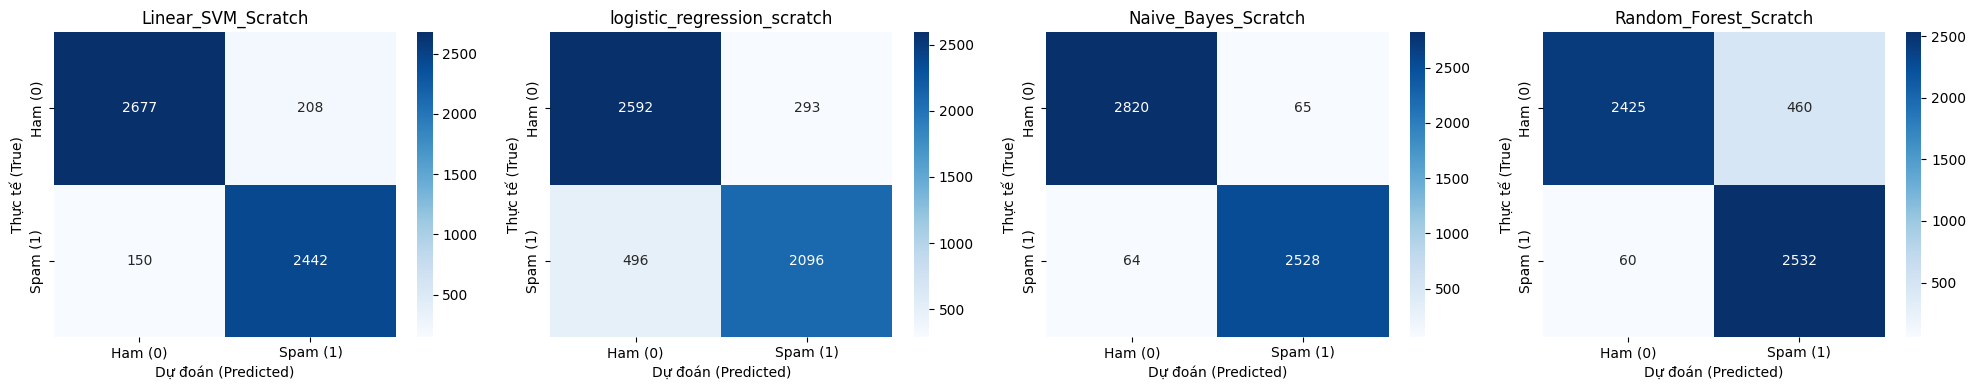

,Mô hình,TPR (Độ nhạy),FPR (Báo nhầm),Accuracy,Precision,Recall,F1_Score,Tham số tốt nhất
0,Naive_Bayes_Scratch,0.9753,0.0225,0.976447,0.974933,0.975309,0.975121,alpha=0.001
1,Linear_SVM_Scratch,0.9421,0.0721,0.884791,0.986118,0.767361,0.863094,"learning_rate=0.1, lambda_param=0.001, n_iters=2000"
2,logistic_regression_scratch,0.8086,0.1016,0.795326,0.982928,0.577546,0.727582,"learning_rate=0.1, epochs=1000"
3,Random_Forest_Scratch,0.9769,0.1594,0.770677,0.971751,0.530864,0.686627,"n_estimators=15, max_depth=20, min_samples_split=2"


In [5]:
pd.set_option('display.max_colwidth', None)
report_df = generate_report(
    model_dir=r'C:\University\May-hoc\Lab\UTH-MACHINE-LEARNING-ASSIGNMENTS-GR02\practice_1\models',
    X_test=X_test, 
    y_test=y_test, 
    plot_cm=True  # Bật cờ này để vẽ 4 biểu đồ cạnh nhau
)
display(report_df)

# 3. Xếp hạng mô hình

Trong bài toán Spam Email Classification, F1 Score là chỉ số quan trọng nhất.

Lý do:

Precision cao giúp giảm số email hợp lệ bị đánh dấu nhầm là Spam.
Recall cao giúp phát hiện được nhiều email Spam hơn.
F1 Score cân bằng giữa Precision và Recall.

Do đó các mô hình sẽ được xếp hạng theo F1 Score giảm dần.

In [6]:
# =====================================================
# Sắp xếp theo F1 Score giảm dần
# =====================================================

ranking_df = report_df.sort_values(
    by="F1_Score",
    ascending=False
)

ranking_df

,Mô hình,TPR (Độ nhạy),FPR (Báo nhầm),Accuracy,Precision,Recall,F1_Score,Tham số tốt nhất
0,Naive_Bayes_Scratch,0.9753,0.0225,0.976447,0.974933,0.975309,0.975121,alpha=0.001
1,Linear_SVM_Scratch,0.9421,0.0721,0.884791,0.986118,0.767361,0.863094,"learning_rate=0.1, lambda_param=0.001, n_iters=2000"
2,logistic_regression_scratch,0.8086,0.1016,0.795326,0.982928,0.577546,0.727582,"learning_rate=0.1, epochs=1000"
3,Random_Forest_Scratch,0.9769,0.1594,0.770677,0.971751,0.530864,0.686627,"n_estimators=15, max_depth=20, min_samples_split=2"


# 4. Trực quan hóa kết quả

Sau khi xếp hạng, kết quả sẽ được biểu diễn bằng biểu đồ cột.

Biểu đồ giúp:

Quan sát trực quan sự khác biệt giữa các mô hình.
Xác định nhanh mô hình có hiệu suất tốt nhất.
Hỗ trợ quá trình lựa chọn mô hình cuối cùng.

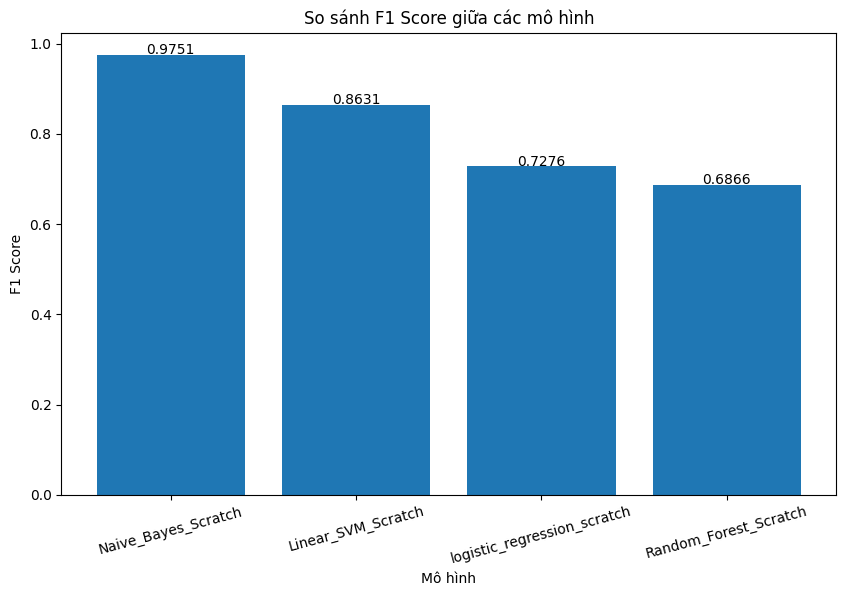

In [7]:
# =====================================================
# Biểu đồ so sánh F1 Score
# =====================================================

plt.figure(figsize=(10,6))

bars = plt.bar(
    ranking_df["Mô hình"],
    ranking_df["F1_Score"]
)

plt.title(
    "So sánh F1 Score giữa các mô hình"
)

plt.xlabel("Mô hình")

plt.ylabel("F1 Score")

plt.xticks(rotation=15)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f"{height:.4f}",
        ha="center"
    )

plt.show()

# 5. So sánh nhiều độ đo đánh giá

Ngoài F1 Score, chúng ta cũng cần quan sát Accuracy, Precision và Recall để có cái nhìn tổng quát hơn về hiệu suất của từng mô hình.

Biểu đồ dưới đây giúp so sánh đồng thời các độ đo đánh giá giữa các mô hình.

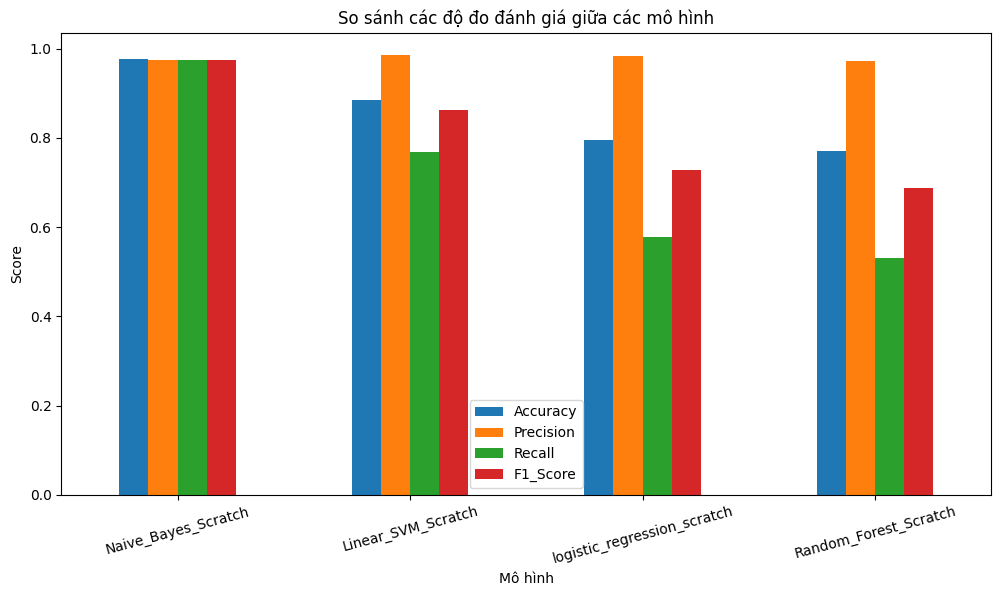

In [8]:
# =====================================================
# So sánh nhiều độ đo đánh giá
# =====================================================

metrics_cols = ["Accuracy", "Precision", "Recall", "F1_Score"]

available_cols = [c for c in metrics_cols if c in report_df.columns]

if available_cols:

    comparison_df = report_df.set_index("Mô hình")[available_cols]

    comparison_df.plot(
        kind="bar",
        figsize=(12,6)
    )

    plt.title(
        "So sánh các độ đo đánh giá giữa các mô hình"
    )

    plt.ylabel("Score")

    plt.xticks(rotation=15)

    plt.legend()

    plt.show()

else:
    print("Không tìm thấy các cột metric cần thiết.")

In [9]:
# =====================================================
# Lấy mô hình tốt nhất
# =====================================================

best_model = ranking_df.iloc[0]

print("=" * 60)
print("MÔ HÌNH TỐT NHẤT")
print("=" * 60)

print(best_model)

MÔ HÌNH TỐT NHẤT
Mô hình             Naive_Bayes_Scratch
TPR (Độ nhạy)                    0.9753
FPR (Báo nhầm)                   0.0225
Accuracy                       0.976447
Precision                      0.974933
Recall                         0.975309
F1_Score                       0.975121
Tham số tốt nhất            alpha=0.001
Name: 0, dtype: object


# 6. Kết luận

Mô hình đứng đầu bảng xếp hạng sẽ được xem là mô hình tốt nhất cho bài toán phân loại email Spam.

Kết luận cuối cùng sẽ được đưa ra dựa trên:

Accuracy
Precision
Recall
F1 Score

đồng thời xem xét khả năng tổng quát hóa của mô hình trên dữ liệu kiểm tra.